# Tech Challenge FIAP - Fase 1
## Case NPS Preditivo

**Aluno:** Matheus Benon Isac

## Objetivo
Analisar os fatores operacionais que impactam a satisfação do cliente em um e-commerce e propor uma abordagem preditiva para antecipar o NPS antes da aplicação da pesquisa.

## 1. Entendimento do negócio

Este projeto parte de uma dor bem clara: hoje, a empresa só consegue medir a satisfação do cliente no fim da jornada, quando a pesquisa de NPS já foi respondida. O problema é que, nesse momento, a empresa já perdeu a chance de atuar preventivamente em muitos casos. Se o cliente teve uma experiência ruim com atraso, atendimento ou qualquer outra fricção operacional, a descoberta acontece tarde demais.

Por isso, o foco deste trabalho é entender quais fatores operacionais estão mais associados à satisfação do cliente em um e-commerce e como esses sinais podem ajudar a empresa a atuar de forma mais proativa, em vez de apenas reagir depois que o NPS já caiu.

O NPS é importante para um e-commerce porque funciona como um termômetro da experiência do cliente. Mais do que uma nota isolada, ele ajuda a mostrar se a jornada foi boa o suficiente para gerar confiança, recomendação e continuidade no relacionamento com a marca. Em um mercado competitivo, isso importa muito, porque a experiência não afeta só a percepção do cliente no momento, mas também o comportamento futuro.

Na prática, esses insights podem ajudar várias áreas da empresa.

- **Logística** pode entender melhor o impacto de atrasos, tempo de entrega e tentativas de entrega na satisfação.
- **Atendimento** pode avaliar se muitos contatos, demora na resolução ou excesso de reclamações estão empurrando clientes para notas mais baixas.
- **Produto e experiência** podem usar esses achados para identificar pontos de atrito na jornada.
- **Pricing e comercial** podem observar se fatores como frete, valor do pedido e desconto estão associados à percepção do cliente.

O NPS também pode impactar o negócio em diferentes níveis.

- **Recompra:** clientes mais satisfeitos tendem a ter maior chance de voltar a comprar.
- **Boca a boca:** clientes promotores tendem a recomendar a marca, enquanto detratores podem espalhar uma percepção negativa.
- **Market share:** uma experiência melhor pode fortalecer retenção, competitividade e diferenciação no mercado.

Para complementar essa análise, também faz sentido olhar para indicadores como benchmark de NPS no setor, SLA de entrega, taxa de recompra, volume de reclamações, CSAT e até sinais da concorrência. Esses indicadores ajudam a colocar os achados em contexto e evitar uma leitura isolada da nota de NPS.

## 2. Definição da target

A variável que melhor representa a satisfação do cliente neste projeto é o `nps_score`. Ela foi escolhida porque é a medida mais direta de satisfação disponível na base, já que traduz em nota a percepção final do cliente sobre a experiência de compra.

Essa escolha faz sentido porque o objetivo do trabalho é justamente entender quais fatores operacionais estão mais associados à satisfação e, em uma etapa posterior, avaliar se esses sinais podem ajudar a antecipar o comportamento do cliente antes da pesquisa. Nesse contexto, o NPS funciona como o principal indicador de resultado da jornada.

De acordo com o enunciado, essa informação é coletada após a experiência de compra, ou seja, ao final da jornada do cliente. Isso é importante porque mostra que o NPS reflete a percepção final da experiência, já impactada por elementos como entrega, atendimento, reclamações e resolução de problemas.

Ao mesmo tempo, existe um risco em usar essa variável de forma inadequada. O primeiro risco é tratar o `nps_score` como se ele explicasse sozinho toda a satisfação do cliente, quando na verdade ele é uma consequência final de vários fatores ao longo da jornada. O segundo é confundir associação com causalidade, assumindo que toda variável relacionada ao NPS necessariamente causa a satisfação ou a insatisfação. Além disso, como a nota é coletada apenas no fim, ela não serve sozinha para ação preventiva; para isso, é preciso olhar para os sinais operacionais que aparecem antes dela.

## 3. Entendimento inicial da base

Com o problema de negócio e a variável alvo já definidos, o próximo passo é entender a base de dados que será usada no projeto. Nesta etapa, o objetivo é verificar a estrutura do dataset, os tipos de variáveis disponíveis e a qualidade inicial das informações. Esse processo é importante para garantir que a análise exploratória e a modelagem sejam construídas sobre uma base consistente e coerente com a pergunta de negócio.

### Preparação do ambiente analítico

*Antes de iniciar a exploração da base, foram importadas as bibliotecas necessárias para manipulação dos dados, visualização gráfica e construção da etapa preditiva do projeto.*

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [96]:
df_nps_ecommerce = pd.read_csv('desafio_nps_fase_1.csv')
df_nps_ecommerce.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


### Conhecimento inicial da base

Nesta etapa, foi feita uma inspeção inicial da base para entender seu tamanho, suas variáveis e os tipos de dados disponíveis. Esse primeiro contato é importante para reconhecer a estrutura do dataset e verificar se as informações presentes fazem sentido para a pergunta de negócio do projeto.

In [97]:
df_nps_ecommerce.shape

(2500, 19)

In [98]:
df_nps_ecommerce.columns.tolist()

['customer_id',
 'customer_age',
 'customer_region',
 'customer_tenure_months',
 'order_id',
 'order_value',
 'items_quantity',
 'discount_value',
 'payment_installments',
 'delivery_time_days',
 'delivery_delay_days',
 'freight_value',
 'delivery_attempts',
 'customer_service_contacts',
 'resolution_time_days',
 'nps_score',
 'repeat_purchase_30d',
 'complaints_count',
 'csat_internal_score']

In [99]:
df_nps_ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

### Validação da qualidade dos dados

Depois de entender a estrutura geral da base, o próximo passo foi verificar sua qualidade inicial. Para isso, foram analisadas estatísticas descritivas, presença de registros duplicados e existência de valores nulos. Essa etapa é importante para garantir que a análise exploratória e a modelagem sejam construídas sobre dados consistentes e confiáveis.

In [100]:
df_nps_ecommerce.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [101]:
df_nps_ecommerce.duplicated().sum()
df_nps_ecommerce.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


## 4. Análise exploratória dos dados

Com o problema de negócio já definido, a variável alvo estabelecida e a base validada, esta etapa passa a focar na exploração dos dados. O objetivo aqui é identificar padrões, relações e possíveis sinais operacionais associados à satisfação do cliente. Mais do que gerar gráficos, a proposta é usar a análise exploratória para transformar os dados em evidências que ajudem a responder à pergunta central do projeto: quais fatores operacionais mais influenciam o NPS e como a empresa pode agir antes da pesquisa final de satisfação?

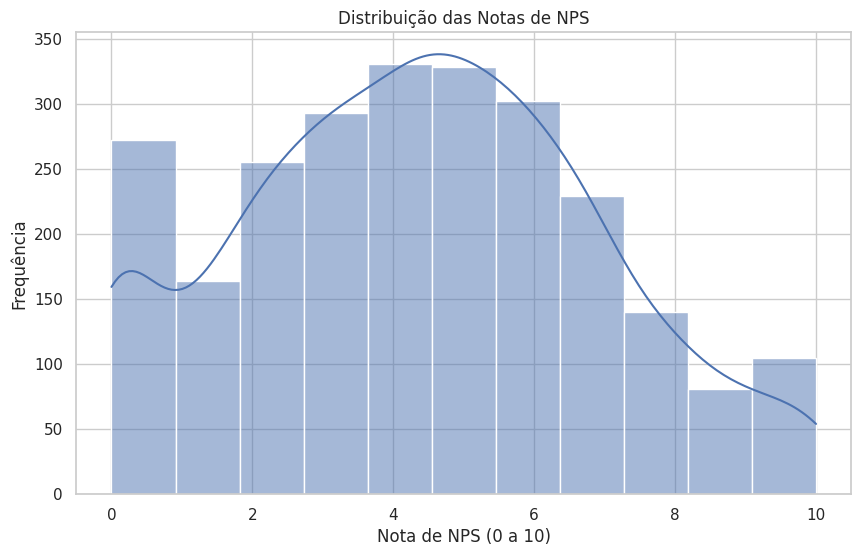

A nota média de satisfação é: 4.38


In [102]:
plt.figure(figsize=(10, 6))
sns.histplot(df_nps_ecommerce['nps_score'], bins=11, kde=True)
plt.title('Distribuição das Notas de NPS')
plt.xlabel('Nota de NPS (0 a 10)')
plt.ylabel('Frequência')
plt.show()

media_nps = df_nps_ecommerce['nps_score'].mean()
print(f"A nota média de satisfação é: {media_nps:.2f}")

### Criação da variável categórica de NPS

Depois de observar a distribuição do `nps_score`, o próximo passo é transformar essa nota em uma categoria de negócio. Para isso, o NPS será segmentado em três grupos: detratores, neutros e promotores. Essa classificação facilita a interpretação da satisfação do cliente e também prepara a base para a etapa de modelagem preditiva.

In [103]:
def categorizar_nps(score):
    if score <= 6:
        return 'Detrator'
    elif score <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

df_nps_ecommerce['nps_category'] = df_nps_ecommerce['nps_score'].apply(categorizar_nps)
df_nps_ecommerce[['nps_score', 'nps_category']].head()

,nps_score,nps_category
0,6.9,Neutro
1,2.4,Detrator
2,4.8,Detrator
3,5.9,Detrator
4,6.1,Neutro


In [104]:
df_nps_ecommerce['nps_category'].value_counts()

,count
nps_category,
Detrator,1851
Neutro,448
Promotor,201


### Atraso na entrega e satisfação do cliente

Após entender a distribuição geral das categorias de NPS, agora é investigar como variáveis operacionais se relacionam com a satisfação. Uma das mais importantes nesse contexto é o atraso na entrega, já que ele representa um ponto crítico da experiência em e-commerce e pode impactar diretamente a percepção final do cliente.

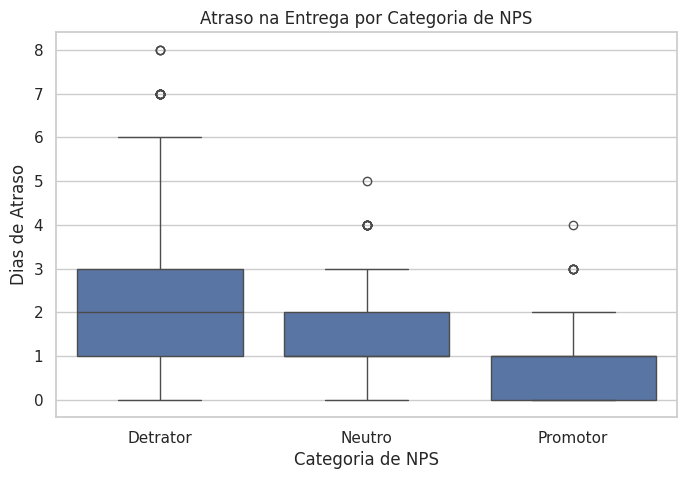

In [105]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_nps_ecommerce,
    x='nps_category',
    y='delivery_delay_days',
    order=['Detrator', 'Neutro', 'Promotor']
)
plt.title('Atraso na Entrega por Categoria de NPS')
plt.xlabel('Categoria de NPS')
plt.ylabel('Dias de Atraso')
plt.show()

*A comparação entre as categorias de NPS mostra que os clientes detratores tendem a apresentar maiores níveis de atraso na entrega do que neutros e promotores. Os promotores concentram os menores atrasos, enquanto os detratores apresentam mediana mais alta e maior dispersão. Esse resultado sugere que o atraso logístico está associado a uma pior percepção da experiência do cliente.*


### Ponto de ruptura na experiência: faixas de atraso

Para investigar se existe um ponto de ruptura na experiência do cliente, a análise a seguir observa a média de NPS por faixas de atraso na entrega. O objetivo é identificar a partir de que nível de atraso a satisfação parece cair de forma mais acentuada.

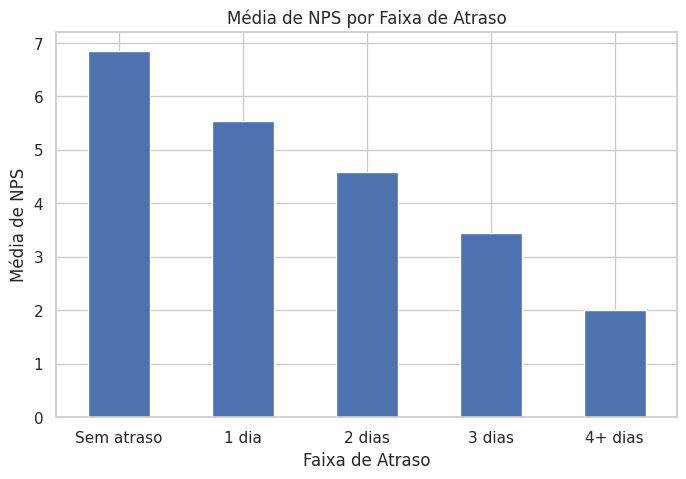

In [106]:
faixas_atraso = pd.cut(
    df_nps_ecommerce['delivery_delay_days'],
    bins=[-1, 0, 1, 2, 3, 8],
    labels=['Sem atraso', '1 dia', '2 dias', '3 dias', '4+ dias']
)

nps_por_faixa_atraso = df_nps_ecommerce.groupby(faixas_atraso, observed=False)['nps_score'].mean()

plt.figure(figsize=(8, 5))
nps_por_faixa_atraso.plot(kind='bar')
plt.title('Média de NPS por Faixa de Atraso')
plt.xlabel('Faixa de Atraso')
plt.ylabel('Média de NPS')
plt.xticks(rotation=0)
plt.show()

A análise por faixas de atraso ajuda a identificar um possível ponto de ruptura na jornada. Caso a média de NPS apresente queda mais forte a partir de determinados níveis de atraso, isso sugere que a experiência do cliente se torna significativamente mais sensível a falhas logísticas a partir desse limite.

### Relação entre reclamações e satisfação

Além do atraso na entrega, a quantidade de reclamações também pode indicar pontos de atrito importantes na jornada do cliente. Nesta etapa, a análise busca verificar se clientes detratores tendem a concentrar mais reclamações do que neutros e promotores.

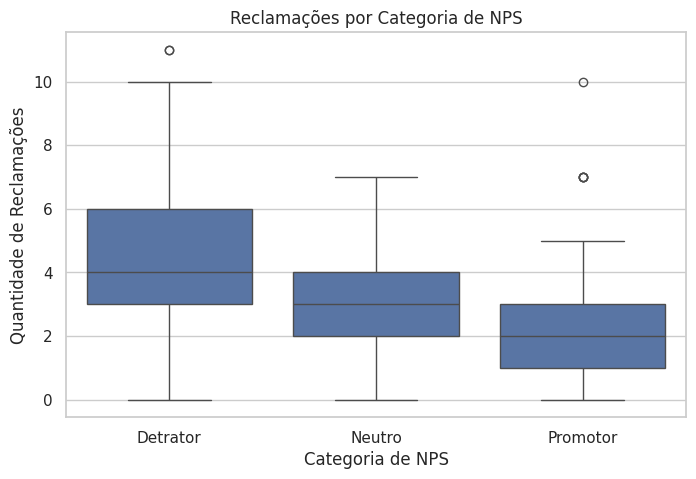

In [107]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_nps_ecommerce,
    x='nps_category',
    y='complaints_count',
    order=['Detrator', 'Neutro', 'Promotor']
)
plt.title('Reclamações por Categoria de NPS')
plt.xlabel('Categoria de NPS')
plt.ylabel('Quantidade de Reclamações')
plt.show()

*A análise mostra que clientes detratores tendem a concentrar mais reclamações do que neutros e promotores. O grupo dos detratores apresenta mediana mais alta e maior dispersão, enquanto os promotores concentram valores menores. Esse resultado sugere que o volume de reclamações está associado a uma pior percepção da experiência do cliente.*

### Relação entre contatos com atendimento e satisfação

Outro sinal importante de atrito na jornada é a quantidade de contatos feitos pelo cliente com o atendimento. Nesta etapa, a análise busca verificar se clientes detratores tendem a acionar mais vezes o suporte do que neutros e promotores, o que pode indicar maior esforço para resolver problemas ao longo da experiência.

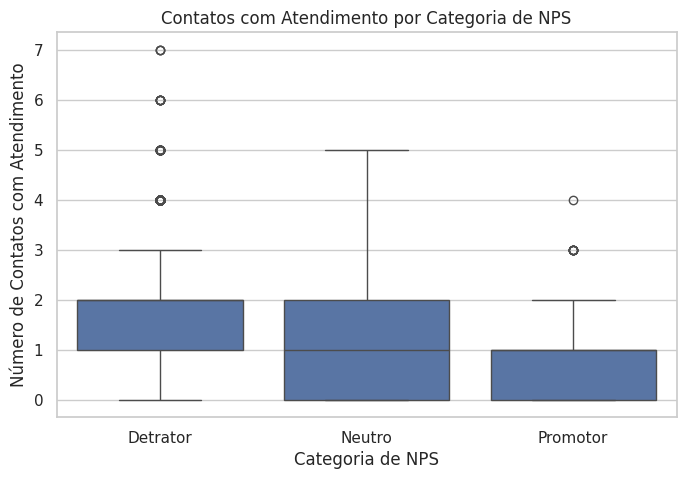

In [108]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_nps_ecommerce,
    x='nps_category',
    y='customer_service_contacts',
    order=['Detrator', 'Neutro', 'Promotor']
)
plt.title('Contatos com Atendimento por Categoria de NPS')
plt.xlabel('Categoria de NPS')
plt.ylabel('Número de Contatos com Atendimento')
plt.show()

*A análise do número de contatos com o atendimento sugere que a frequência de interação com o suporte funciona como um sinal importante de atrito na jornada. Enquanto os promotores se concentram em 0 ou 1 contato, os detratores apresentam maior dispersão e casos mais extremos, o que indica maior esforço para resolver problemas ao longo da experiência. Esse padrão sugere que jornadas menos fluidas e com necessidade de múltiplas interações com o suporte estão associadas a uma pior percepção do cliente.*

### Relação entre tempo de resolução e satisfação

Além da quantidade de contatos com o atendimento, o tempo necessário para resolver um problema também pode impactar a percepção do cliente sobre a experiência. Nesta etapa, a análise busca verificar se clientes detratores tendem a enfrentar tempos de resolução mais altos do que neutros e promotores.

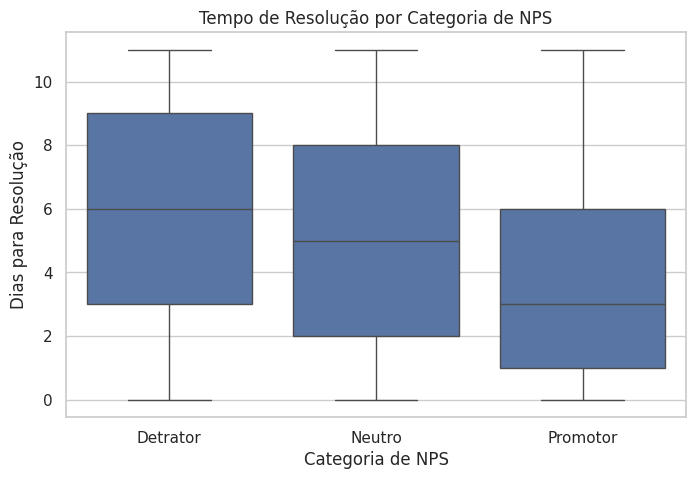

In [109]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_nps_ecommerce,
    x='nps_category',
    y='resolution_time_days',
    order=['Detrator', 'Neutro', 'Promotor']
)
plt.title('Tempo de Resolução por Categoria de NPS')
plt.xlabel('Categoria de NPS')
plt.ylabel('Dias para Resolução')
plt.show()

*A análise mostra que o tempo de resolução dos problemas tende a ser maior entre os clientes detratores e menor entre os promotores. A diferença entre as medianas dos grupos sugere que jornadas com solução mais demorada estão associadas a uma percepção mais negativa da experiência. Em termos operacionais, esse resultado pode indicar fragilidade na agilidade de atendimento e no cumprimento de um nível de serviço compatível com uma boa experiência do cliente.*

### Relação entre recompra em 30 dias e satisfação

Além dos fatores operacionais, também é importante observar um possível reflexo de negócio da satisfação: a recompra em até 30 dias. Nesta etapa, a análise busca verificar se clientes promotores tendem a apresentar maior probabilidade de recompra do que neutros e detratores.

In [110]:
recompra_por_nps = pd.crosstab(
    df_nps_ecommerce['nps_category'],
    df_nps_ecommerce['repeat_purchase_30d'],
    normalize='index'
) * 100

recompra_por_nps

repeat_purchase_30d,0,1
nps_category,,
Detrator,100.000000,0.000000
Neutro,96.205357,3.794643
Promotor,0.000000,100.000000


### Perfil do cliente: NPS por região

Além dos fatores operacionais, também é útil observar se existem diferenças de satisfação entre perfis de clientes. Nesta etapa, a análise investiga se a região geográfica do cliente está associada a diferenças relevantes no NPS.

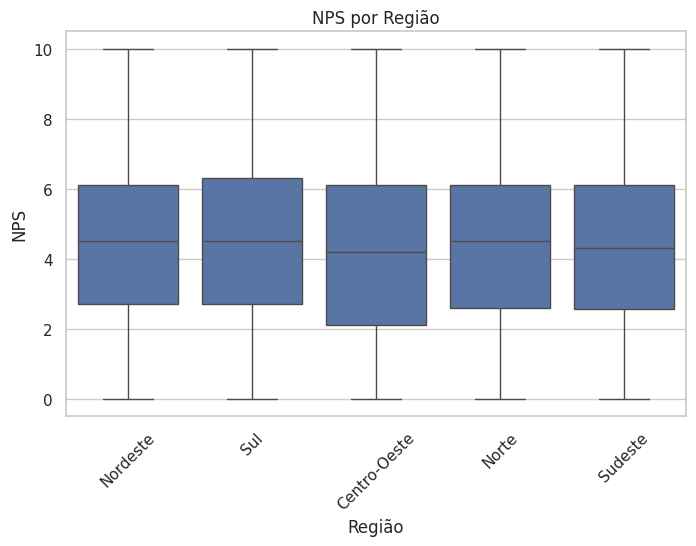

In [111]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_nps_ecommerce, x='customer_region', y='nps_score')
plt.title('NPS por Região')
plt.xlabel('Região')
plt.ylabel('NPS')
plt.xticks(rotation=45)
plt.show()

A comparação por região permite observar se determinados perfis geográficos concentram níveis mais altos ou mais baixos de satisfação. Caso existam diferenças relevantes entre os grupos, isso pode indicar necessidade de investigação adicional sobre contexto logístico, atendimento ou características operacionais específicas de cada região.

### Mapa de correlação entre variáveis numéricas

Para complementar a análise exploratória, foi gerado um mapa de correlação entre as variáveis numéricas da base. O objetivo é identificar quais fatores apresentam relações mais fortes com o `nps_score` e observar possíveis associações entre os próprios indicadores operacionais.

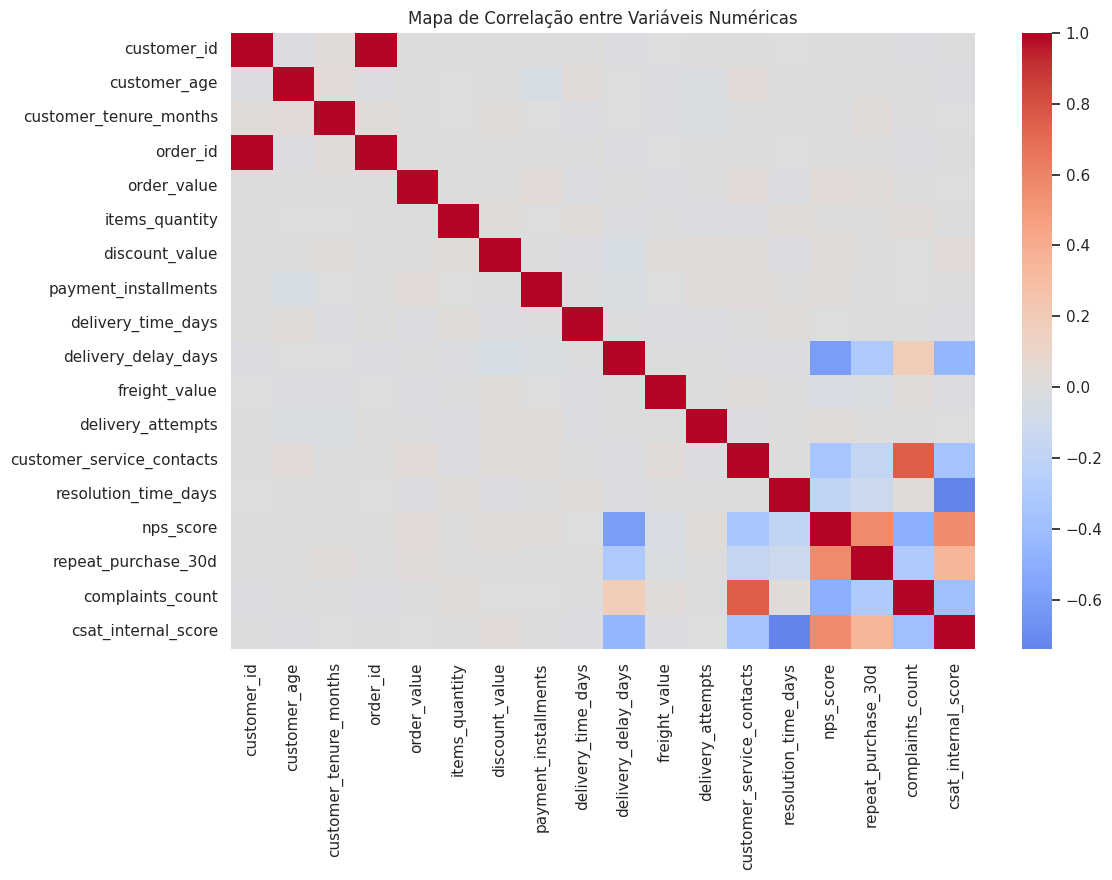

In [112]:
plt.figure(figsize=(12, 8))
correlacao_numerica = df_nps_ecommerce.select_dtypes(include=np.number).corr()
sns.heatmap(correlacao_numerica, cmap='coolwarm', center=0)
plt.title('Mapa de Correlação entre Variáveis Numéricas')
plt.show()

O mapa de correlação reforça os principais achados da análise exploratória. O `nps_score` apresenta relação positiva mais forte com `repeat_purchase_30d` e `csat_internal_score`, e relação negativa com variáveis ligadas a atrito na jornada, como `complaints_count`, `customer_service_contacts`, `resolution_time_days` e `delivery_delay_days`. Em termos de negócio, esse padrão sugere que satisfação mais alta tende a caminhar junto com recompra e melhor avaliação interna, enquanto atrasos, reclamações e maior esforço para resolver problemas estão associados a pior percepção da experiência.

## 5. Modelagem preditiva

Depois de identificar os principais fatores associados à satisfação do cliente, o próximo passo é avaliar se essas variáveis podem ser usadas para antecipar a categoria de NPS. Para isso, será construída uma abordagem preditiva de classificação, com o objetivo de estimar se um cliente tende a ser detrator, neutro ou promotor a partir de sinais operacionais e de comportamento disponíveis na base.

In [113]:
features_modelo = [
    'customer_age',
    'customer_tenure_months',
    'order_value',
    'items_quantity',
    'discount_value',
    'payment_installments',
    'delivery_time_days',
    'delivery_delay_days',
    'freight_value',
    'delivery_attempts',
    'customer_service_contacts',
    'resolution_time_days',
    'complaints_count'
]

target_modelo = 'nps_category'

X = df_nps_ecommerce[features_modelo]
y = df_nps_ecommerce[target_modelo]

X.head()

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count
0,63,14,139.73,4,39.35,4,2,2,55.53,3,0,4,3
1,20,1,458.95,2,9.51,10,6,4,28.23,3,0,10,3
2,46,111,507.06,5,42.82,6,6,1,40.99,1,4,5,7
3,52,117,302.19,2,19.58,9,5,2,35.24,3,1,11,4
4,56,50,253.06,1,29.37,11,13,1,39.32,1,1,0,3


### Separação entre treino e teste

Para avaliar a capacidade de generalização do modelo, a base será dividida em dois conjuntos: treino e teste. O conjunto de treino será usado para ensinar o modelo a reconhecer padrões, enquanto o conjunto de teste servirá para verificar como ele se comporta em dados que não viu anteriormente.

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Formato de X_train:", X_train.shape)
print("Formato de X_test:", X_test.shape)
print("Formato de y_train:", y_train.shape)
print("Formato de y_test:", y_test.shape)

Formato de X_train: (2000, 13)
Formato de X_test: (500, 13)
Formato de y_train: (2000,)
Formato de y_test: (500,)


### Treinamento do modelo preditivo

Como todas as variáveis de entrada selecionadas são numéricas, o processo de modelagem pode ser feito de forma mais direta. Nesta etapa, será treinado um modelo de classificação do tipo Random Forest, com o objetivo de aprender padrões que ajudem a prever se um cliente tende a ser detrator, neutro ou promotor com base em sinais operacionais e características da jornada.

In [115]:
modelo_nps = RandomForestClassifier(random_state=42)
modelo_nps.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Avaliação inicial do modelo

Depois do treinamento, o próximo passo é verificar como o modelo se comporta em dados que não foram usados no aprendizado. Para isso, serão geradas previsões sobre o conjunto de teste e avaliadas métricas que indicam o nível de acerto do modelo para cada categoria de NPS.

In [116]:
y_pred = modelo_nps.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8

Relatório de Classificação:

              precision    recall  f1-score   support

    Detrator       0.83      0.97      0.89       370
      Neutro       0.62      0.33      0.43        90
    Promotor       0.58      0.28      0.37        40

    accuracy                           0.80       500
   macro avg       0.68      0.53      0.57       500
weighted avg       0.77      0.80      0.77       500



### Matriz de confusão

Para complementar a avaliação do modelo, foi gerada uma matriz de confusão. Essa visualização ajuda a entender em quais categorias o modelo acerta mais e onde estão os principais erros de classificação, facilitando a interpretação prática do seu comportamento.

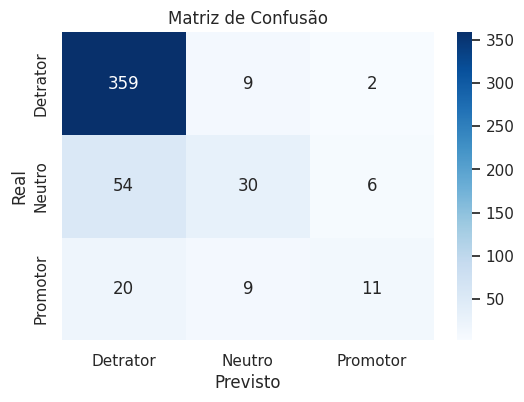

In [117]:
cm = confusion_matrix(y_test, y_pred, labels=['Detrator', 'Neutro', 'Promotor'])

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Detrator', 'Neutro', 'Promotor'],
    yticklabels=['Detrator', 'Neutro', 'Promotor']
)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

*A matriz de confusão mostra que o modelo teve desempenho muito superior na identificação de clientes detratores do que na distinção entre neutros e promotores. A maior parte dos detratores foi classificada corretamente, enquanto uma parcela relevante de neutros e promotores foi prevista como detrator. Esse comportamento é coerente com o desbalanceamento da base, fortemente concentrada em clientes com baixa satisfação. Em termos práticos, o modelo se mostra mais útil como ferramenta de alerta para risco de insatisfação do que como mecanismo preciso para separar, com alto nível de confiança, todos os níveis de satisfação do cliente.*

### Interpretação prática do modelo

Os resultados mostram que o modelo apresenta bom desempenho geral, com acurácia de 80% no conjunto de teste. O principal destaque está na identificação de clientes detratores, com recall de 97%, o que indica alta capacidade de reconhecer casos de maior risco de insatisfação.

Por outro lado, o desempenho para neutros e promotores foi mais limitado. A matriz de confusão mostrou que uma parcela relevante desses clientes foi classificada como detrator, o que sugere dificuldade do modelo em distinguir com precisão as classes minoritárias da base.

Esse comportamento é coerente com o desbalanceamento dos dados, fortemente concentrados em clientes detratores. Em termos práticos, isso indica que o modelo tem maior utilidade como ferramenta de alerta para risco de experiência negativa do que como mecanismo preciso para separar, com alto nível de confiança, todos os níveis de satisfação do cliente.

### Tentativa de ajuste de balanceamento

Foi testada uma alternativa com balanceamento de classes no Random Forest, com o objetivo de melhorar a identificação de neutros e promotores. No entanto, essa abordagem resultou em piora do desempenho geral do modelo e não trouxe ganho prático para as classes minoritárias. Por isso, a versão original foi mantida como a opção mais adequada para este contexto.

Também foram deixadas de fora da modelagem variáveis como `csat_internal_score` e `repeat_purchase_30d`, por apresentarem risco de estarem muito próximas do desfecho final da jornada e, portanto, introduzirem viés ou vazamento de informação na previsão.

### Variáveis mais importantes para o modelo

Para complementar a interpretação do modelo, foi analisada a importância relativa das variáveis de entrada no Random Forest. Essa leitura ajuda a entender quais sinais tiveram maior peso na previsão da categoria de NPS.

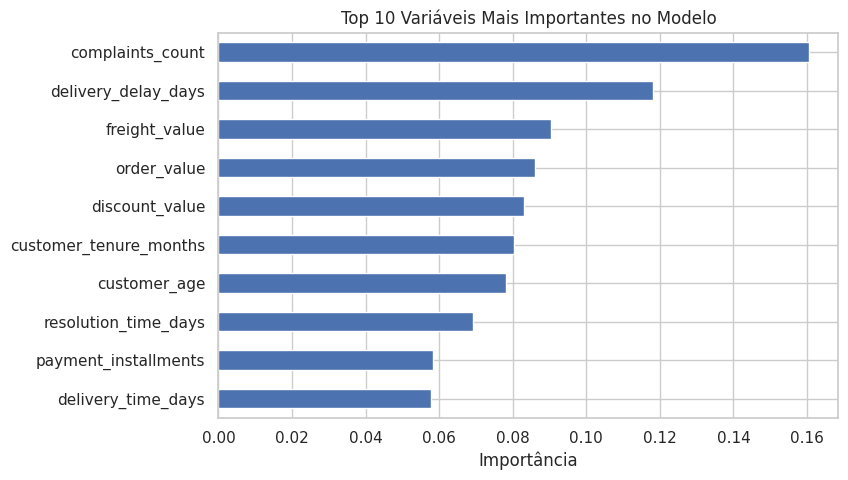

In [118]:
importancias = pd.Series(modelo_nps.feature_importances_, index=features_modelo).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importancias.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Variáveis Mais Importantes no Modelo')
plt.xlabel('Importância')
plt.show()

A importância das variáveis no modelo não deve ser interpretada como prova de causalidade, mas ajuda a indicar quais sinais operacionais e de jornada tiveram maior peso na previsão da satisfação. Isso reforça a utilidade do modelo como ferramenta complementar de priorização e monitoramento preventivo.

## 6. Conclusões e recomendações

A análise realizada mostrou que a satisfação do cliente, representada pelo NPS, está fortemente associada a fatores operacionais da jornada. Entre os principais pontos observados, destacam-se o atraso na entrega, a quantidade de reclamações, o número de contatos com o atendimento e o tempo de resolução de problemas.

De forma geral, clientes detratores apresentaram maiores níveis de atrito operacional, enquanto promotores concentraram jornadas mais fluidas, com menor necessidade de suporte e menor tempo de resolução. Além disso, a análise de recompra reforçou que a satisfação não é apenas uma percepção subjetiva, mas também um indicador com potencial impacto em retenção e continuidade do relacionamento com a marca.

A modelagem preditiva mostrou que é possível antecipar, com utilidade prática, clientes com maior risco de insatisfação. Embora o modelo tenha apresentado limitações para distinguir com precisão neutros e promotores, ele se mostrou especialmente eficaz para identificar detratores, o que pode apoiar ações preventivas por parte da empresa.

Com base nos resultados, a empresa poderia priorizar ações voltadas para:
- redução do atraso logístico;
- melhoria da resolução no atendimento;
- diminuição da necessidade de múltiplos contatos com o suporte;
- monitoramento de sinais de atrito ao longo da jornada antes da pesquisa de NPS.

Como limitação, este projeto utiliza uma base histórica específica e variáveis já observadas ao final da jornada, o que exige cautela na generalização dos resultados e no uso do modelo para decisão operacional sem validações adicionais.